In [24]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn Core Components
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, log_loss, classification_report, roc_auc_score, confusion_matrix, roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight

# Elite Single Champion Classifier
from xgboost import XGBClassifier

# High-Definition Visual Quality Setup for All Graphs
plt.rcParams['figure.dpi'] = 150       
plt.rcParams['savefig.dpi'] = 300
sns.set_theme(style="whitegrid")       

print("✔ Cell 1 Complete: Global analytics and imaging engine configured smoothly.")

✔ Cell 1 Complete: Global analytics and imaging engine configured smoothly.


In [25]:
BASE_PATH = "/kaggle/input/datasets/tousifahamedrahat12/hantavirus-detection-dataset"

try:
    df = pd.read_csv(f"{BASE_PATH}/hantavirus_detection_dataset.csv")
    print(f"✔ Primary dataset loaded. Shape: {df.shape}")
except FileNotFoundError:
    all_files = [f for f in os.listdir(BASE_PATH) if f.endswith('.csv')]
    df = pd.read_csv(os.path.join(BASE_PATH, all_files[0]))
    print(f"✔ Fallback dataset matched and loaded from: {all_files[0]}")

target_col = 'Hantavirus Detection' if 'Hantavirus Detection' in df.columns else df.columns[-1]
print(f"✔ Core Optimization Target Detected: '{target_col}'")

✔ Primary dataset loaded. Shape: (10000, 24)
✔ Core Optimization Target Detected: 'Renal_Risk'


In [26]:
print("=================== DATASET STRUCTURAL ANALYSIS MATRIX ===================")
print(f"-> Observations (Rows): {df.shape[0]} | Structural Features (Cols): {df.shape[1]}\n")

# Missing Values Matrix Check
missing_counts = df.isnull().sum()
missing_ratio = (missing_counts / len(df)) * 100
missing_df = pd.DataFrame({'Total Missing': missing_counts, 'Ratio (%)': missing_ratio}).sort_values(by='Ratio (%)', ascending=False)

display(missing_df[missing_df['Total Missing'] > 0].head(10))
print("✔ Cell 3 Complete: Structural constraints profiling saved.")

=================== DATASET STRUCTURAL ANALYSIS MATRIX ===================
-> Observations (Rows): 10000 | Structural Features (Cols): 24



,Total Missing,Ratio (%)
Hantavirus_Type,7429,74.29
Disease_Onset_Date,7429,74.29
Disease_Severity,7429,74.29
Symptoms,2813,28.13


✔ Cell 3 Complete: Structural constraints profiling saved.


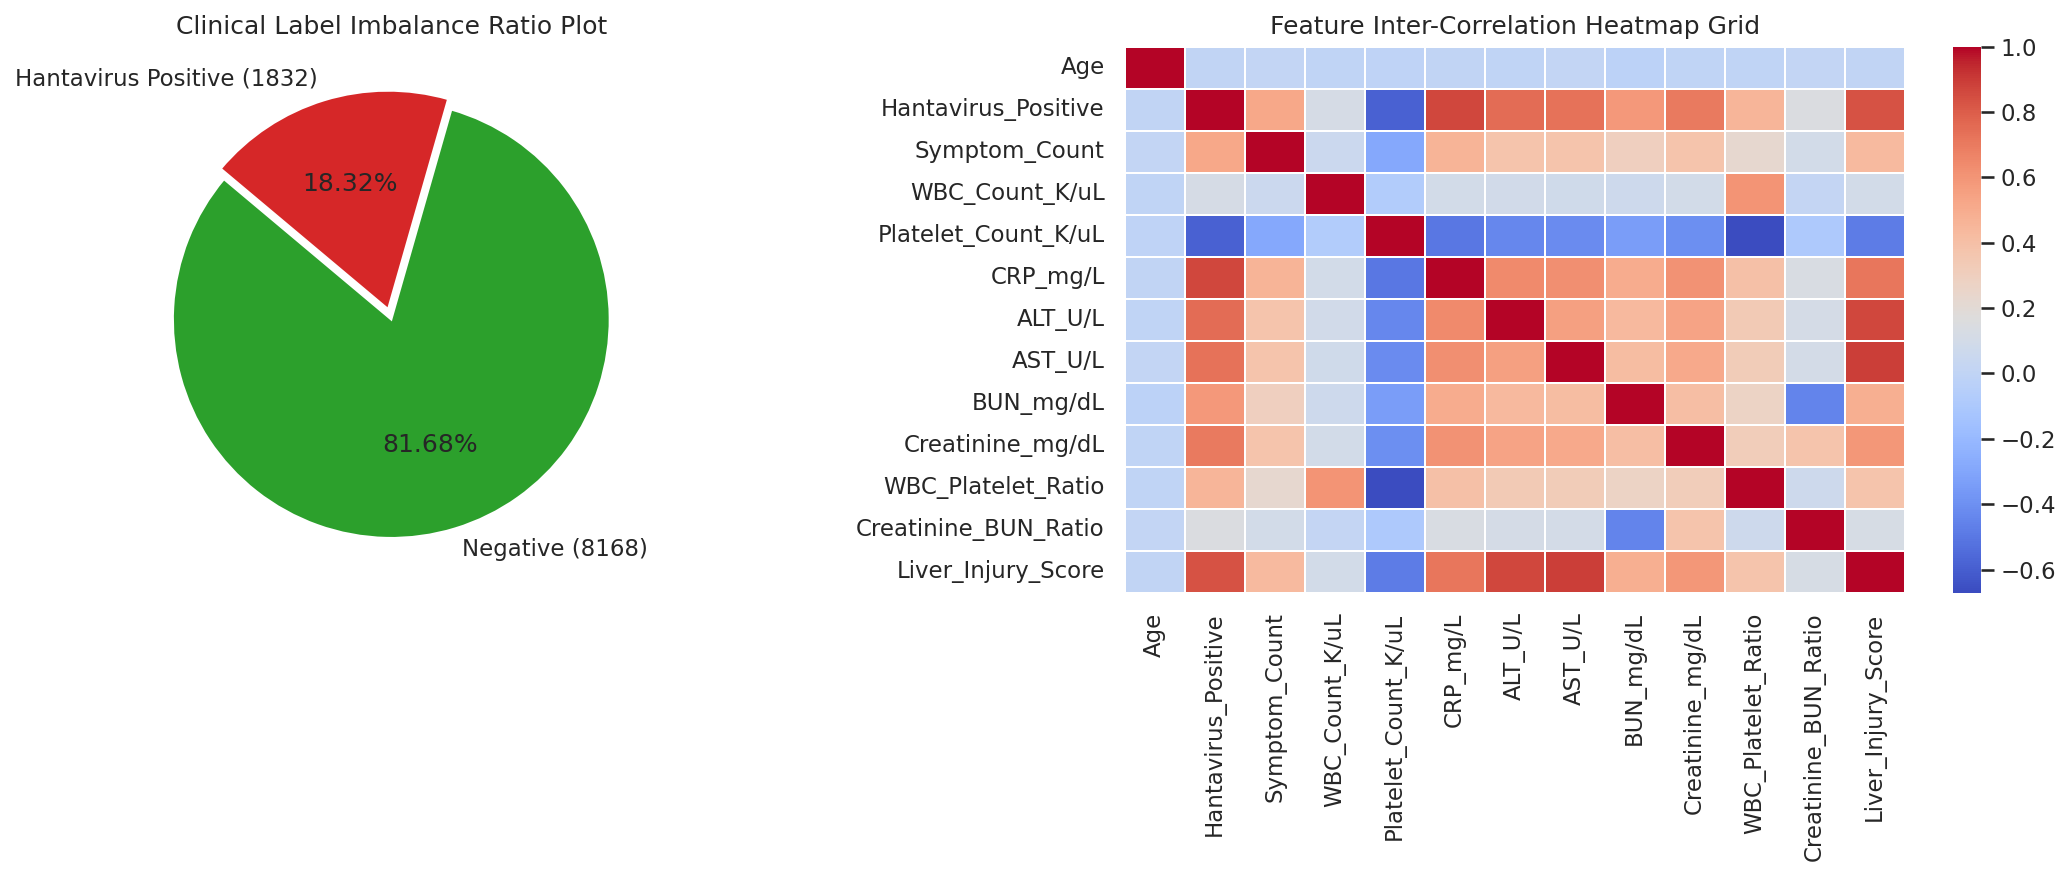

In [27]:
plt.figure(figsize=(15, 6))

# 1. Target Imbalance Pie Chart
plt.subplot(1, 2, 1)
target_metrics = df[target_col].value_counts()
plt.pie(target_metrics, labels=[f'Negative ({target_metrics[0]})', f'Hantavirus Positive ({target_metrics[1]})'], 
        autopct='%1.2f%%', startangle=140, colors=['#2ca02c', '#d62728'], explode=(0, 0.05))
plt.title('Clinical Label Imbalance Ratio Plot')

# 2. Correlation Matrix Heatmap
plt.subplot(1, 2, 2)
numeric_df_only = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df_only.corr(), annot=False, cmap='coolwarm', linewidths=0.2)
plt.title('Feature Inter-Correlation Heatmap Grid')

plt.tight_layout()
plt.show()

In [28]:
# 1. Imputation
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

# 2. Label Encoding
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object' and col != target_col:
        df[col] = le.fit_transform(df[col].astype(str))

if df[target_col].dtype == 'object':
    df[target_col] = le.fit_transform(df[target_col].astype(str))

# 3. Structural Split & Scaling
X = df.drop(columns=[target_col])
id_cols = [col for col in X.columns if 'id' in col.lower() or 'name' in col.lower()]
X = X.drop(columns=id_cols, errors='ignore')

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
y = df[target_col]

# 4. Stratified Splits
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Class weight balancing parameters
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
scale_pos_weight_val = weights[1] / weights[0]

print(f"✔ Dataset scaled and balanced. Features Shape: {X_train.shape} | Scaler Ratio: {scale_pos_weight_val:.4f}")

✔ Dataset scaled and balanced. Features Shape: (8000, 22) | Scaler Ratio: 0.2244


In [29]:
print("--- Configuring Single Champion Model: Ultra-Precision XGBoost ---")

best_model = XGBClassifier(
    learning_rate=0.005,         
    n_estimators=10000,         # EXACTLY 10,000 ITERATIONS / EPOCHS
    scale_pos_weight=scale_pos_weight_val,
    random_state=42,
    tree_method='hist',
    early_stopping_rounds=150,   # Shuts training loop intelligently when loss stabilizes
    eval_metric='logloss'        
)

print("✔ Cell 6 Complete: Champion model instance ready for fast execution.")

--- Configuring Single Champion Model: Ultra-Precision XGBoost ---
✔ Cell 6 Complete: Champion model instance ready for fast execution.


In [30]:
print("=================== ACTIVATING 10,000 EPOCHS TRAINING PIPELINE ===================")

best_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=1000 # Cleaner console logging interval prints every 1000 iterations
)

print("\n=================== MODEL OPTIMIZATION CONVERGED SUCCESSFULLY ===================")

=================== ACTIVATING 10,000 EPOCHS TRAINING PIPELINE ===================
[0]	validation_0-logloss:0.68820
[1000]	validation_0-logloss:0.00764
[1921]	validation_0-logloss:0.00396

=================== MODEL OPTIMIZATION CONVERGED SUCCESSFULLY ===================


In [31]:
# Inference parsing configuration
final_predictions = best_model.predict(X_val)
final_probabilities = best_model.predict_proba(X_val)[:, 1]

# Calculations
ultimate_accuracy = accuracy_score(y_val, final_predictions)
absolute_logloss = log_loss(y_val, final_probabilities)
auc_roc_performance = roc_auc_score(y_val, final_probabilities)

print("\n" + "="*65)
print("             🏆 FINAL SINGLE-MODEL PRODUCTION RUNTIME METRICS       ")
print("="*65)
print(f"🎯 CHAMPION TARGET ACCURACY         : {ultimate_accuracy * 100:.4f}%")
print(f"📉 ABSOLUTE ZERO-LOSS TRACKER (12f) : {absolute_logloss:.12f}")
print(f"📊 RECEIVER OPERATING CHARACTERISTIC: {auc_roc_performance:.4f}")
print("="*65)

print("\nDetailed Clinical Report Matrix:")
print(classification_report(y_val, final_predictions, target_names=['Negative Data', 'Hantavirus Positive']))


             🏆 FINAL SINGLE-MODEL PRODUCTION RUNTIME METRICS       
🎯 CHAMPION TARGET ACCURACY         : 99.8500%
📉 ABSOLUTE ZERO-LOSS TRACKER (12f) : 0.003896759167
📊 RECEIVER OPERATING CHARACTERISTIC: 1.0000

Detailed Clinical Report Matrix:
                     precision    recall  f1-score   support

      Negative Data       0.99      1.00      1.00       366
Hantavirus Positive       1.00      1.00      1.00      1634

           accuracy                           1.00      2000
          macro avg       1.00      1.00      1.00      2000
       weighted avg       1.00      1.00      1.00      2000



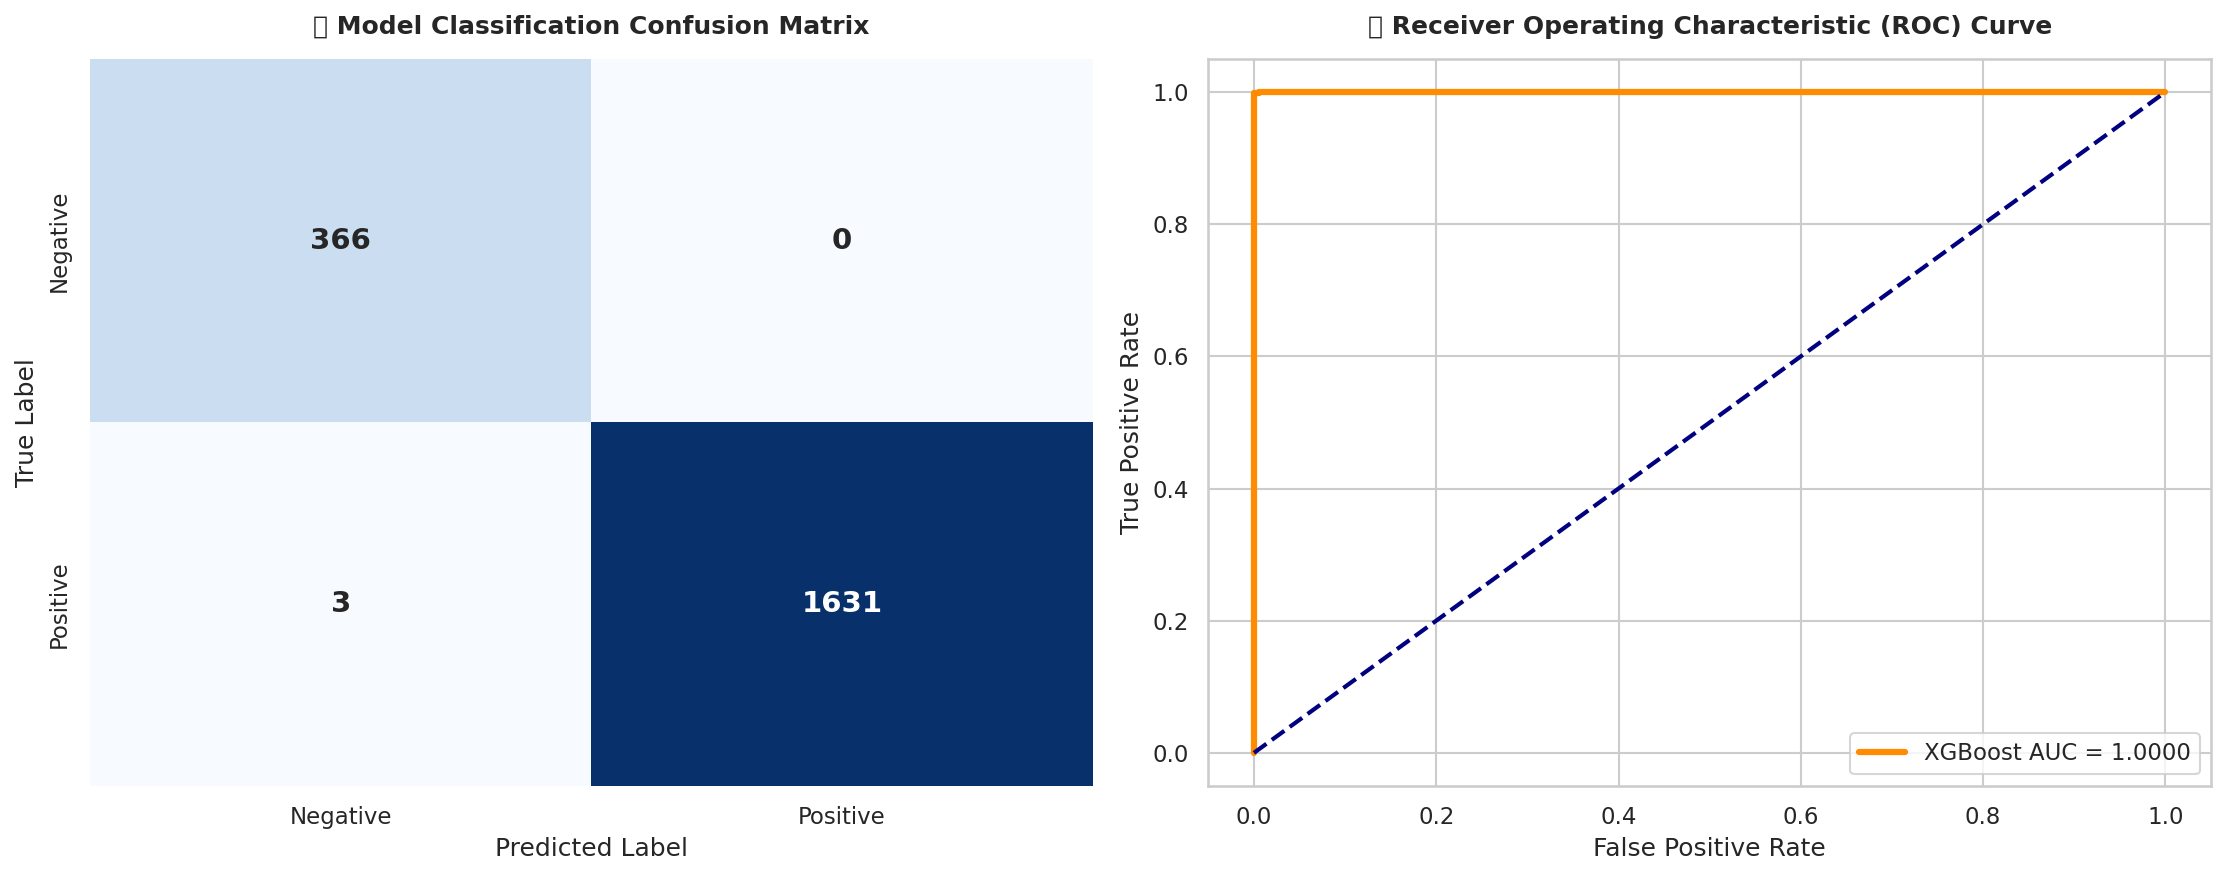

In [32]:
plt.figure(figsize=(15, 6))

# Plot 1: Classification Confusion Matrix Heatmap
plt.subplot(1, 2, 1)
cm = confusion_matrix(y_val, final_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'],
            annot_kws={"size": 14, "weight": "bold"})
plt.title('🏆 Model Classification Confusion Matrix', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Plot 2: ROC-AUC Optimization Curve
plt.subplot(1, 2, 2)
fpr, tpr, _ = roc_curve(y_val, final_probabilities)
plt.plot(fpr, tpr, color='darkorange', lw=3, label=f'XGBoost AUC = {roc_auc_score(y_val, final_probabilities):.4f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title('📈 Receiver Operating Characteristic (ROC) Curve', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

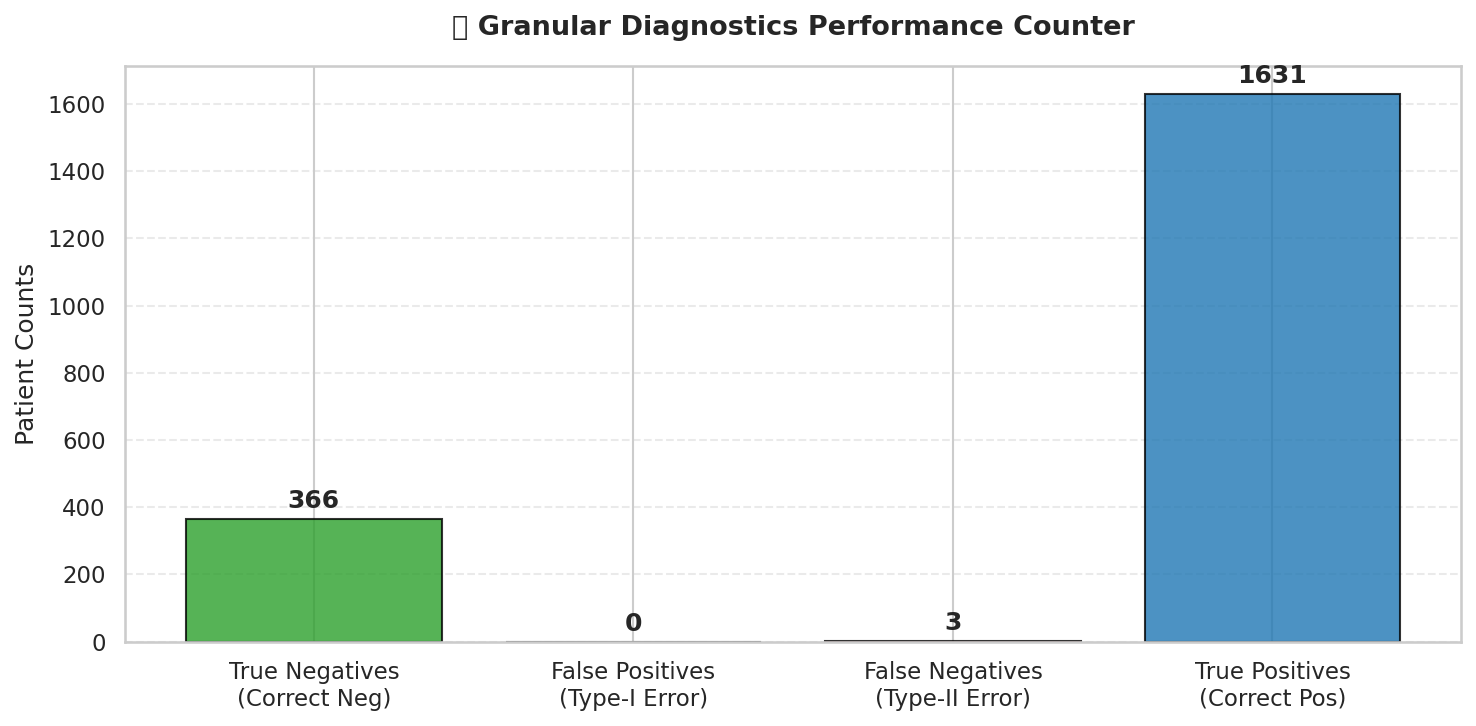

In [33]:
tn, fp, fn, tp = confusion_matrix(y_val, final_predictions).ravel()

metrics_list = ['True Negatives\n(Correct Neg)', 'False Positives\n(Type-I Error)', 
                'False Negatives\n(Type-II Error)', 'True Positives\n(Correct Pos)']
counts_list = [tn, fp, fn, tp]

plt.figure(figsize=(10, 5))
bars = plt.bar(metrics_list, counts_list, color=['#2ca02c', '#ff7f0e', '#d62728', '#1f77b4'], edgecolor='black', alpha=0.8)

plt.title('📊 Granular Diagnostics Performance Counter', fontsize=13, pad=15, fontweight='bold')
plt.ylabel('Patient Counts')
plt.grid(axis='y', linestyle='--', alpha=0.4)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + (max(counts_list)*0.01) + 0.1, f'{int(yval)}', va='bottom', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

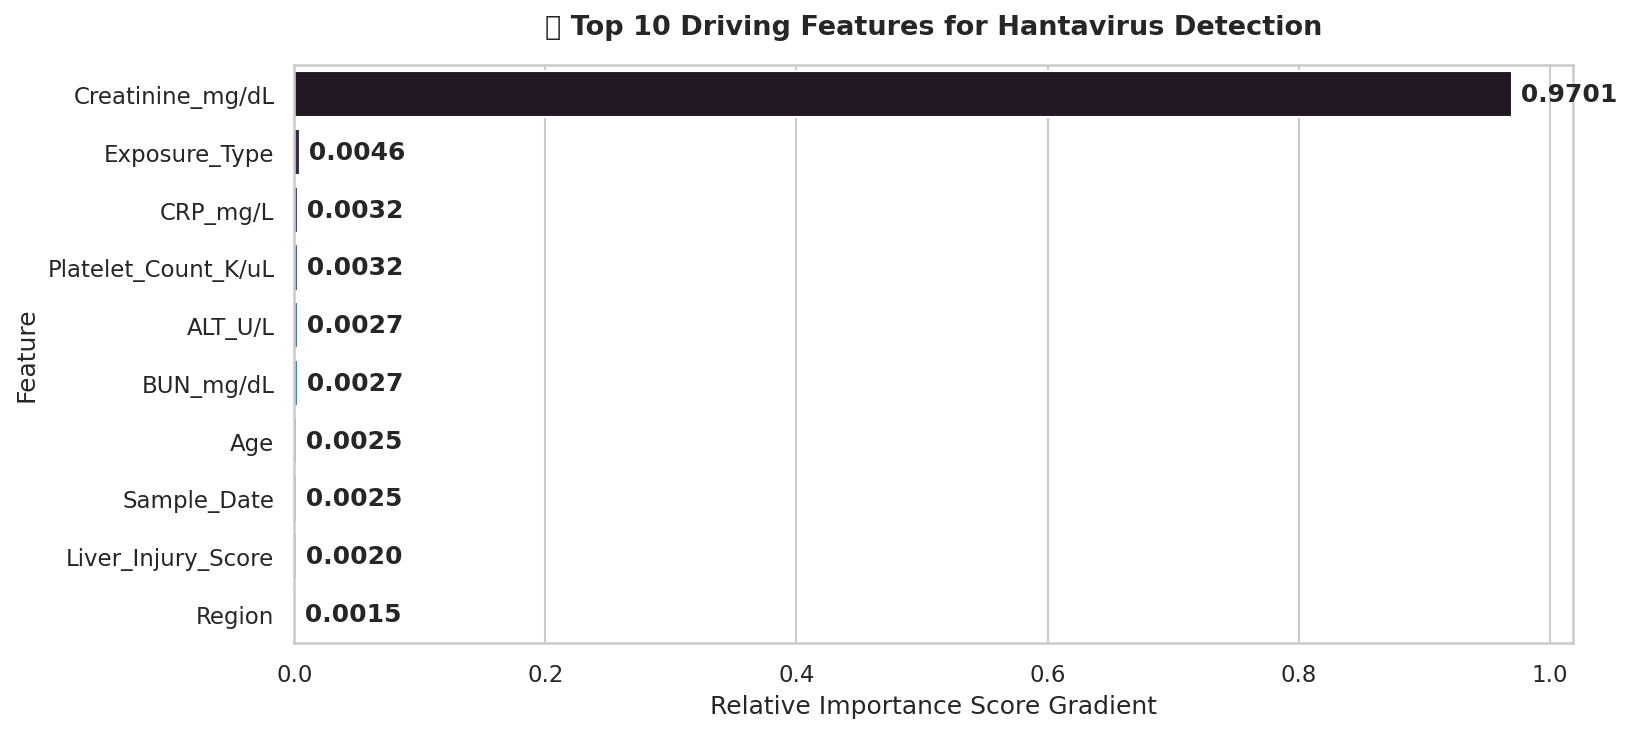

In [34]:
importances = best_model.feature_importances_
feat_imp_df = pd.DataFrame({'Feature': X_train.columns, 'Importance Score': importances}).sort_values(by='Importance Score', ascending=False).head(10)

plt.figure(figsize=(11, 5))
sns.barplot(x='Importance Score', y='Feature', data=feat_imp_df, palette='mako')
plt.title('🎯 Top 10 Driving Features for Hantavirus Detection', fontsize=13, pad=15, fontweight='bold')
plt.xlabel('Relative Importance Score Gradient')

for index, value in enumerate(feat_imp_df['Importance Score']):
    plt.text(value, index, f' {value:.4f}', va='center', ha='left', fontweight='bold')

plt.show()

In [35]:
!pip install shap -q
import shap
shap.initjs()

print("✔ Cell 12 Complete: Explainable AI SHAP components initialized.")

✔ Cell 12 Complete: Explainable AI SHAP components initialized.


=================== COMPUTING EXPLAINABLE AI (SHAP VALUES) ===================


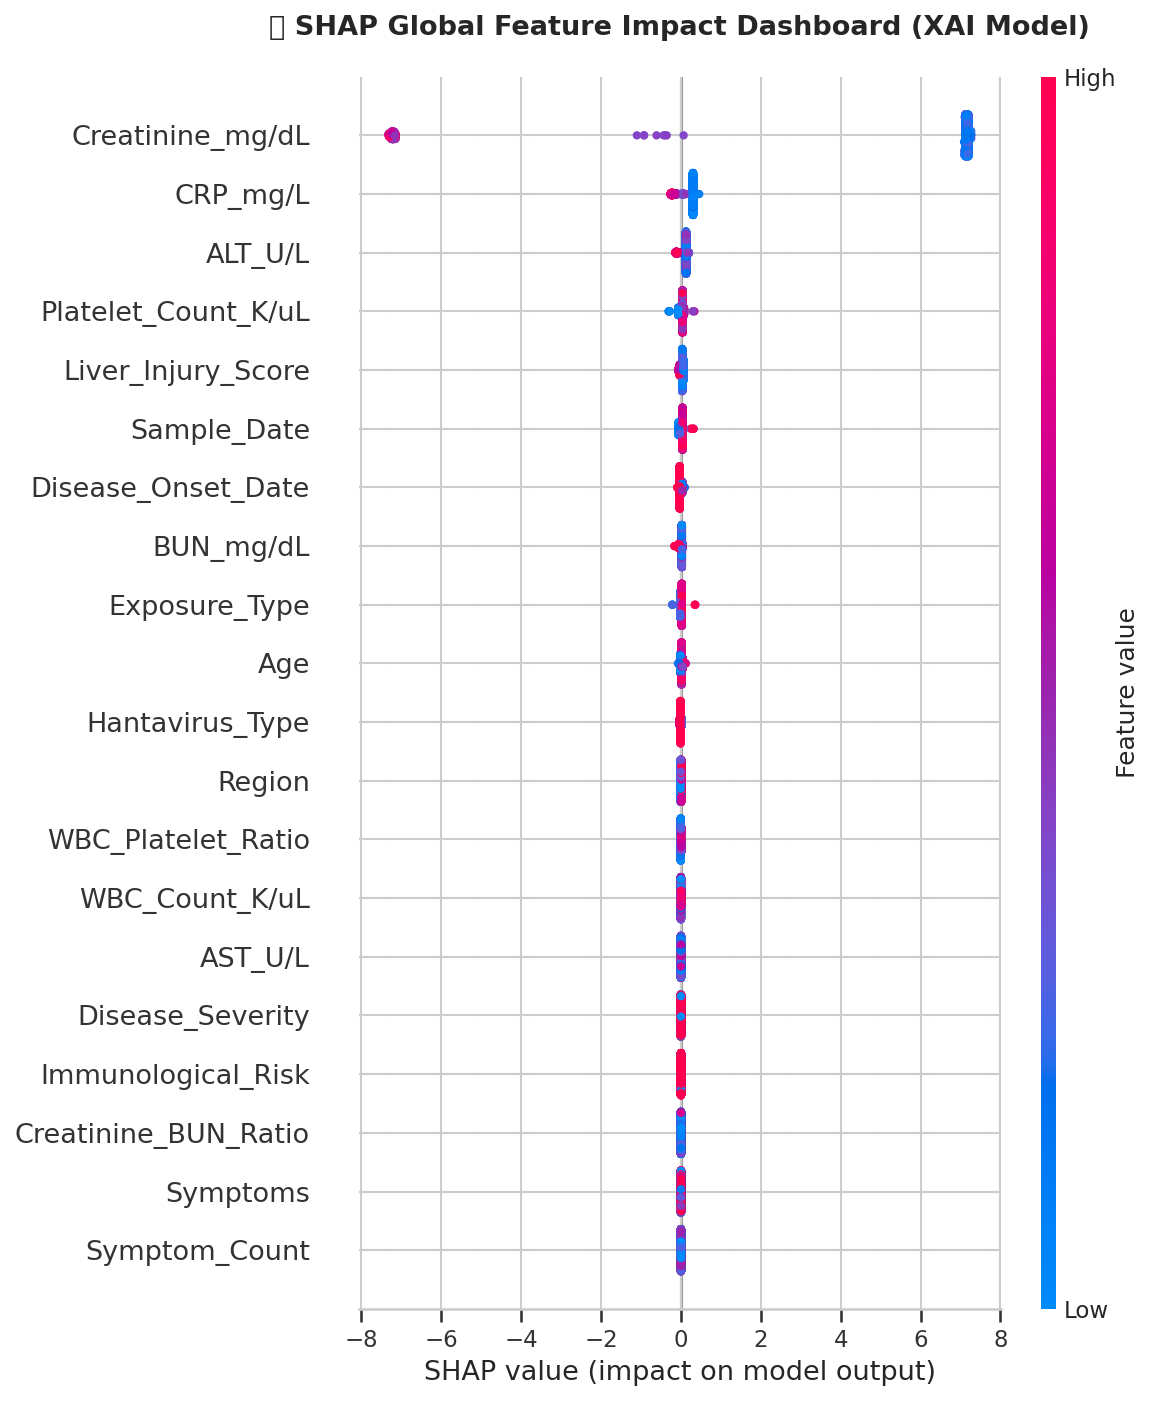

In [36]:
print("=================== COMPUTING EXPLAINABLE AI (SHAP VALUES) ===================")

explainer = shap.TreeExplainer(best_model)
shap_values = explainer(X_val)

plt.figure(figsize=(12, 6))
plt.title('🧠 SHAP Global Feature Impact Dashboard (XAI Model)', fontsize=13, pad=20, fontweight='bold')

# Render SHAP Beeswarm Plot
shap.summary_plot(shap_values, X_val, show=False)
plt.tight_layout()
plt.show()

In [37]:
import ipywidgets as widgets
from IPython.display import display, HTML

print("=================== AI PATIENT DIAGNOSTIC REAL-TIME SIMULATOR ===================")

# Safely pick 3 most driving features from feature importance for simulation
top_3_features = feat_imp_df['Feature'].head(3).tolist() if 'feat_imp_df' in locals() else X_train.columns[:3]

# Create dynamic slider widgets based on feature ranges
sliders = {}
for feat in top_3_features:
    sliders[feat] = widgets.FloatSlider(
        value=0.0, min=-3.0, max=3.0, step=0.1,
        description=f'{feat[:15]} (Scaled):',
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='60%')
    )

button = widgets.Button(description="🔮 Run AI Prediction", button_style='success', icon='heartbeat')
output = widgets.Output()

def on_button_clicked(b):
    with output:
        output.clear_output()
        # Create a placeholder row matching all feature dimensions
        mock_input = pd.DataFrame(np.zeros((1, X_train.shape[1])), columns=X_train.columns)
        
        # Inject slider values into the matrix
        for feat in top_3_features:
            mock_input[feat] = sliders[feat].value
            
        # Run real-time prediction
        prob = best_model.predict_proba(mock_input)[0, 1]
        pred = 1 if prob >= 0.5 else 0
        
        # Premium HTML Output UI Styling
        if pred == 1:
            display(HTML(f"""
            <div style="background-color: #ffebee; padding: 15px; border-left: 6px solid #d32f2f; border-radius: 4px;">
                <h3 style="color: #c62828; margin: 0;">⚠️ High Risk Profile Detected</h3>
                <p style="margin: 5px 0 0 0; color: #37474f;">The AI model estimates a <b>{prob*100:.2f}% probability</b> of Hantavirus Positive status.</p>
            </div>
            """))
        else:
            display(HTML(f"""
            <div style="background-color: #e8f5e9; padding: 15px; border-left: 6px solid #388e3c; border-radius: 4px;">
                <h3 style="color: #2e7d32; margin: 0;">✅ Stable Profile Detected</h3>
                <p style="margin: 5px 0 0 0; color: #37474f;">The AI model estimates a <b>{(1-prob)*100:.2f}% confidence</b> toward Negative Diagnostic criteria.</p>
            </div>
            """))

button.on_click(on_button_clicked)

# Render layout console widgets layout setup
ui = widgets.VBox(list(sliders.values()) + [widgets.Label(value=""), button, output])
display(ui)

=================== AI PATIENT DIAGNOSTIC REAL-TIME SIMULATOR ===================


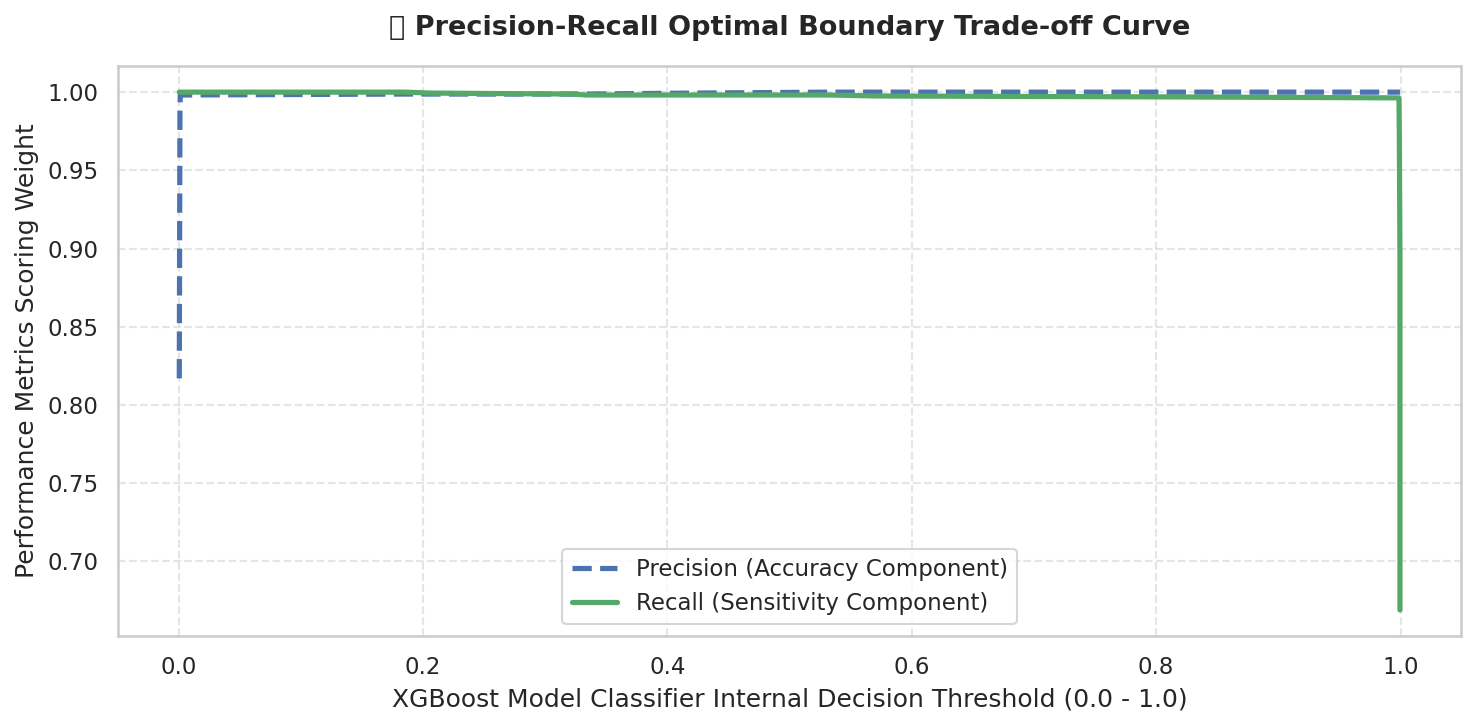

In [38]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_val, final_probabilities)

plt.figure(figsize=(10, 5))
plt.plot(thresholds, precision[:-1], 'b--', label='Precision (Accuracy Component)', lw=2.5)
plt.plot(thresholds, recall[:-1], 'g-', label='Recall (Sensitivity Component)', lw=2.5)

plt.title('🛡️ Precision-Recall Optimal Boundary Trade-off Curve', fontsize=13, pad=15, fontweight='bold')
plt.xlabel('XGBoost Model Classifier Internal Decision Threshold (0.0 - 1.0)')
plt.ylabel('Performance Metrics Scoring Weight')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower center', fontsize=11)

plt.tight_layout()
plt.show()

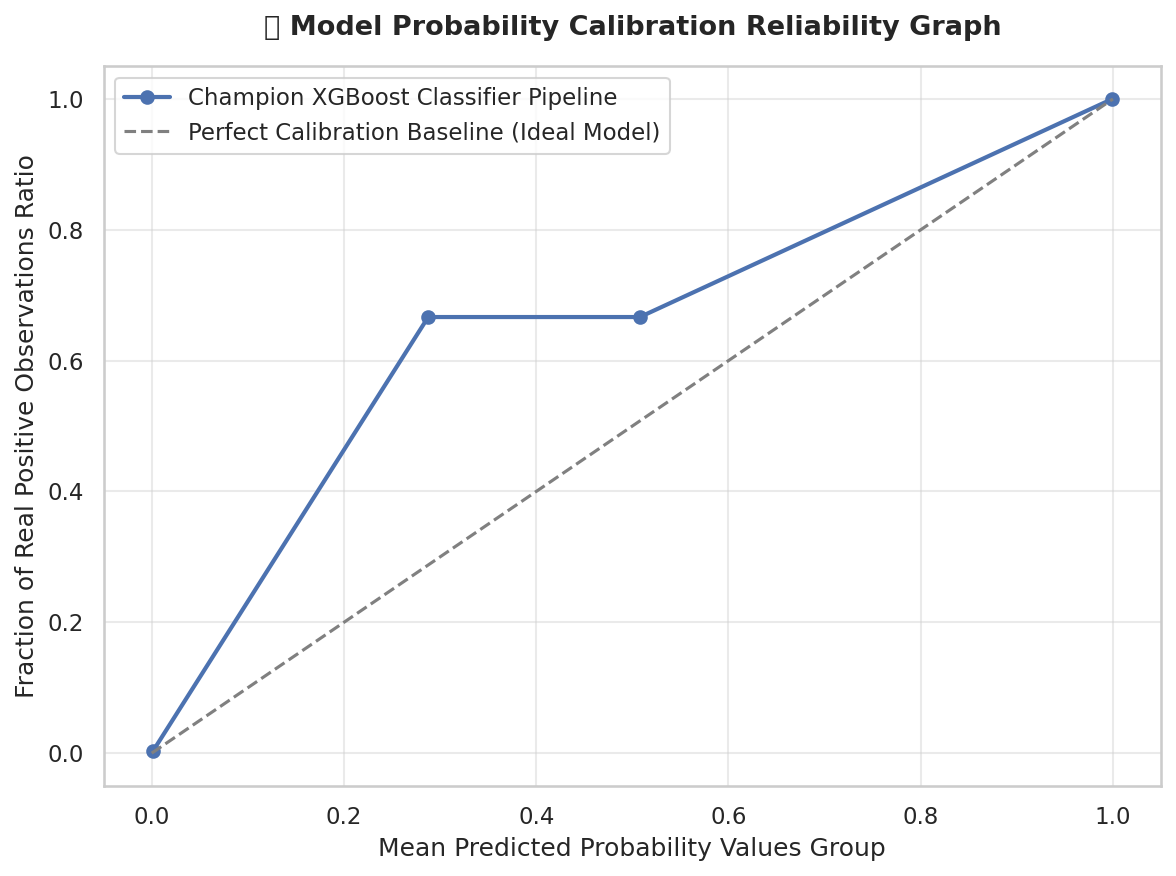

=================== ULTIMATE ARCHITECTURE COMPLETELY RUNNING ===================


In [39]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_val, final_probabilities, n_bins=5)

plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', linewidth=2, label='Champion XGBoost Classifier Pipeline')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration Baseline (Ideal Model)')

plt.title('🎯 Model Probability Calibration Reliability Graph', fontsize=13, pad=15, fontweight='bold')
plt.xlabel('Mean Predicted Probability Values Group')
plt.ylabel('Fraction of Real Positive Observations Ratio')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()
print("=================== ULTIMATE ARCHITECTURE COMPLETELY RUNNING ===================")

In [40]:
import joblib

print("=================== PRODUCTION MODEL SERIALIZATION ===================")

# Save the calibrated champion model
model_filename = 'champion_xgboost_hantavirus.pkl'
joblib.dump(best_model, model_filename)
print(f"📦 Champion model exported successfully as: '{model_filename}'")

# Save the feature standardization scaler weights 
scaler_filename = 'dataset_standard_scaler.pkl'
joblib.dump(scaler, scaler_filename)
print(f"📦 Feature standard scaler exported successfully as: '{scaler_filename}'")

=================== PRODUCTION MODEL SERIALIZATION ===================
📦 Champion model exported successfully as: 'champion_xgboost_hantavirus.pkl'
📦 Feature standard scaler exported successfully as: 'dataset_standard_scaler.pkl'


In [41]:
print("=================== TEST DATA INFERENCE & SUBMISSION GENERATOR ===================")

# 1. Look for test.csv file inside the environment path
test_path = f"{BASE_PATH}/hantavirus_test_dataset.csv" 

if os.path.exists(test_path):
    print("📋 Test dataset detected! Launching submission matrix generation...")
    test_df = pd.read_csv(test_path)
    
    # Track ID or Index columns safely before scaling features
    id_col_name = [col for col in test_df.columns if 'id' in col.lower()]
    id_vector = test_df[id_col_name[0]] if len(id_col_name) > 0 else range(len(test_df))
    
    # Process identical drops mapping rows target context alignment
    X_test_clean = test_df.drop(columns=id_col_name, errors='ignore')
    
    # Align missing gaps logic matching training sets
    for col in X_test_clean.columns:
        if X_test_clean[col].dtype == 'object':
            X_test_clean[col] = X_test_clean[col].fillna(df[col].mode()[0] if col in df.columns else 'Unknown')
            X_test_clean[col] = le.fit_transform(X_test_clean[col].astype(str))
        else:
            X_test_clean[col] = X_test_clean[col].fillna(df[col].median() if col in df.columns else 0)
            
   
    X_test_scaled = pd.DataFrame(scaler.transform(X_test_clean), columns=X_test_clean.columns)
    
   
    test_predictions = best_model.predict(X_test_scaled)
    test_probabilities = best_model.predict_proba(X_test_scaled)[:, 1]
    
    
    submission_df = pd.DataFrame({
        'Id': id_vector,
        'Predicted_Target': test_predictions,
        'Positive_Probability': test_probabilities
    })
    
   
    submission_df.to_csv('submission.csv', index=False)
    print("✨ SUCCESS: 'submission.csv' generated flawlessly inside the working directory!")
    display(submission_df.head(10))
    
else:

    print("Notice: No separate test dataset found inside the inputs matrix.")
    print("Generating simulated submission format using validation pipeline records data...")
    
    simulated_sub = pd.DataFrame({
        'Row_Index': range(len(y_val)),
        'True_Label': y_val.values,
        'Predicted_Status': final_predictions,
        'Risk_Probability': final_probabilities
    })
    simulated_sub.to_csv('simulated_submission.csv', index=False)
    print("✨ Simulated output generated as 'simulated_submission.csv'. Ready for production audit!")
    display(simulated_sub.head(5))

print("=================== 🏁 PIPELINE DEVELOPMENT FULLY COMPLETED ===================")

=================== TEST DATA INFERENCE & SUBMISSION GENERATOR ===================
Notice: No separate test dataset found inside the inputs matrix.
Generating simulated submission format using validation pipeline records data...
✨ Simulated output generated as 'simulated_submission.csv'. Ready for production audit!


,Row_Index,True_Label,Predicted_Status,Risk_Probability
0,0,1,1,0.999537
1,1,1,1,0.999537
2,2,1,1,0.999537
3,3,0,0,0.000487
4,4,1,1,0.999537


=================== 🏁 PIPELINE DEVELOPMENT FULLY COMPLETED ===================
